# <center>Simple Linear Regression</center>


### Importing Needed packages

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd '/content/drive/MyDrive/fml/Regression'

/content/drive/MyDrive/fml/Regression


In [ ]:
!pwd

/content/drive/MyDrive/Reskill/fml/Regression


## Reading the data in

In [4]:
df = pd.read_csv(r"Copy of TSLA.csv", parse_dates=['Date'])
# take a look at the dataset
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-15,148.399994,150.626007,142.000000,145.966003,145.966003,117885000
1,2020-04-16,143.388000,151.889999,141.343994,149.042007,149.042007,103289500
2,2020-04-17,154.455994,154.990005,149.531998,150.778000,150.778000,65641000
3,2020-04-20,146.539993,153.113998,142.442001,149.272003,149.272003,73733000
4,2020-04-21,146.024002,150.666000,134.757996,137.343994,137.343994,101045500


In [5]:
df['Yesterday'] = df['Close'].shift(-1)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Yesterday
0,2020-04-15,148.399994,150.626007,142.000000,145.966003,145.966003,117885000,149.042007
1,2020-04-16,143.388000,151.889999,141.343994,149.042007,149.042007,103289500,150.778000
2,2020-04-17,154.455994,154.990005,149.531998,150.778000,150.778000,65641000,149.272003
3,2020-04-20,146.539993,153.113998,142.442001,149.272003,149.272003,73733000,137.343994
4,2020-04-21,146.024002,150.666000,134.757996,137.343994,137.343994,101045500,146.421997


In [7]:
windows = [5, 10, 15, 20]

for w in windows:
  df[f'ma{w}'] = df['Close'].rolling(w, min_periods=1).mean()

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Yesterday,ma5,ma10,ma15,ma20
0,2020-04-15,148.399994,150.626007,142.000000,145.966003,145.966003,117885000,149.042007,145.966003,145.966003,145.966003,145.966003
1,2020-04-16,143.388000,151.889999,141.343994,149.042007,149.042007,103289500,150.778000,147.504005,147.504005,147.504005,147.504005
2,2020-04-17,154.455994,154.990005,149.531998,150.778000,150.778000,65641000,149.272003,148.595337,148.595337,148.595337,148.595337
3,2020-04-20,146.539993,153.113998,142.442001,149.272003,149.272003,73733000,137.343994,148.764503,148.764503,148.764503,148.764503
4,2020-04-21,146.024002,150.666000,134.757996,137.343994,137.343994,101045500,146.421997,146.480401,146.480401,146.480401,146.480401


#### Creating train and test dataset
Train/Test Split involves splitting the dataset into training and testing sets respectively, which are mutually exclusive. After which, you train with the training set and test with the testing set. 
This will provide a more accurate evaluation on out-of-sample accuracy because the testing dataset is not part of the dataset that have been used to train the data. It is more realistic for real world problems.

This means that we know the outcome of each data point in this dataset, making it great to test with! And since this data has not been used to train the model, the model has no knowledge of the outcome of these data points. So, in essence, it is truly an out-of-sample testing.

Lets split our dataset into train and test sets, 80% of the entire data for training, and the 20% for testing. We create a mask to select random rows using __np.random.rand()__ function: 

In [8]:
start_test_date = '2021-01-01'
data_train = df[['Date', 'Yesterday',	'ma5',	'ma10',	'ma15',	'ma20', 'Close']]
train_set = data_train[data_train['Date'] < start_test_date]
test_set = data_train[data_train['Date'] >= start_test_date]
display(train_set.tail())
test_set.head()

,Date,Yesterday,ma5,ma10,ma15,ma20,Close
177,2020-12-24,663.690002,658.590002,645.469006,638.461336,623.862003,661.770020
178,2020-12-28,665.989990,652.328003,650.839007,642.771338,627.758502,663.690002
179,2020-12-29,694.780029,655.554004,653.455005,644.386670,632.678003,665.989990
180,2020-12-30,705.669983,666.442004,659.608008,647.380005,638.179004,694.780029
181,2020-12-31,729.770020,678.380005,667.898004,654.126005,645.021503,705.669983


,Date,Yesterday,ma5,ma10,ma15,ma20,Close
182,2021-01-04,735.109985,691.980005,675.285004,660.972672,651.841003,729.770020
183,2021-01-05,755.979980,706.264001,679.296002,669.314005,658.644504,735.109985
184,2021-01-06,816.039978,724.261999,689.908002,677.057336,664.355502,755.979980
185,2021-01-07,880.020020,748.513989,707.477997,689.243335,672.663501,816.039978
186,2021-01-08,811.190002,783.383997,730.882001,706.393335,686.440503,880.020020


In [9]:
test_set.dropna(inplace=True)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


### Simple Regression Model
Linear Regression fits a linear model with coefficients $\theta = (\theta_1, ..., \theta_n)$ to minimize the 'residual sum of squares' between the independent x in the dataset, and the dependent y by the linear approximation. 

#### Modeling
Using sklearn package to model data.

In [10]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train_set[['Yesterday',	'ma5',	'ma10',	'ma15',	'ma20']])
train_y = np.asanyarray(train_set['Close'])
regr.fit (train_x, train_y)
# The coefficients
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [ 0.50224166  0.78122274 -0.37855864  0.11497247 -0.02062346]
Intercept:  0.12451140668173366


As mentioned before, __Coefficient__ and __Intercept__ in the simple linear regression, are the parameters of the fit line. 
Given that it is a simple linear regression, with only 2 parameters, and knowing that the parameters are the intercept and slope of the line, sklearn can estimate them directly from our data. 
Notice that all of the data must be available to traverse and calculate the parameters.


#### Plot outputs

we can plot the fit line over the data:

#### Evaluation
we compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics provide a key role in the development of a model, as it provides insight to areas that require improvement.

There are different model evaluation metrics, lets use MSE here to calculate the accuracy of our model based on the test set: 
<ul>
    <li> Mean absolute error: It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just average error.</li>
    <li> Mean Squared Error (MSE): Mean Squared Error (MSE) is the mean of the squared error. It’s more popular than Mean absolute error because the focus is geared more towards large errors. This is due to the squared term exponentially increasing larger errors in comparison to smaller ones.</li>
    <li> Root Mean Squared Error (RMSE): This is the square root of the Mean Square Error. </li>
    <li> R-squared is not error, but is a popular metric for accuracy of your model. It represents how close the data are to the fitted regression line. The higher the R-squared, the better the model fits your data. Best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).</li>
</ul>

In [11]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test_set[['Yesterday',	'ma5',	'ma10',	'ma15',	'ma20']])
test_y = np.asanyarray(test_set['Close'])
test_y_hat = regr.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_hat - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_hat - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_hat , test_y) )

Mean absolute error: 17.39
Residual sum of squares (MSE): 523.95
R2-score: 0.93


In [12]:
test_set['yhat'] = test_y_hat

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [13]:
test_set.head()

,Date,Yesterday,ma5,ma10,ma15,ma20,Close,yhat
182,2021-01-04,735.109985,691.980005,675.285004,660.972672,651.841003,729.770020,716.833354
183,2021-01-05,755.979980,706.264001,679.296002,669.314005,658.644504,735.109985,737.774432
184,2021-01-06,816.039978,724.261999,689.908002,677.057336,664.355502,755.979980,778.754736
185,2021-01-07,880.020020,748.513989,707.477997,689.243335,672.663501,816.039978,824.412825
186,2021-01-08,811.190002,783.383997,730.882001,706.393335,686.440503,880.020020,809.912626


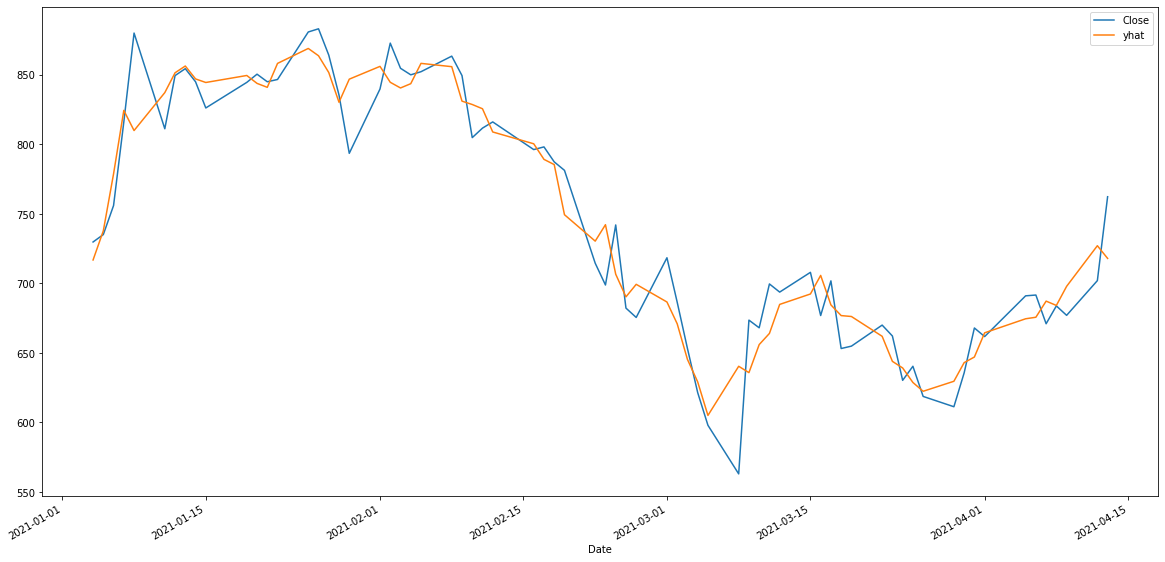

In [14]:
test_set.plot(x='Date', y=['Close', "yhat"], figsize=(20, 10))

#### Training with Cross validation

In [15]:

# Import scikit-learn libraries
from sklearn.model_selection import KFold

kf5 = KFold(n_splits=5, shuffle=False)
model = linear_model.LinearRegression()

train_x = np.asanyarray(cdf[['ENGINESIZE']])
train_y = np.asanyarray(cdf[['CO2EMISSIONS']])
print(np.shape(train_x))
print(np.shape(train_y))
i = 1
for train_index, test_index in kf5.split(train_x):
    X_train =train_x[train_index]
    X_test = train_x[test_index]
    y_train =train_y[train_index]
    y_test = train_y[test_index]
        
    #Train the model
    model.fit(X_train, y_train) #Training the model
    print(f"Accuracy for the fold no. {i} on the test set: {r2_score(y_test, model.predict(X_test))}")
    i += 1

NameError: ignored

In [ ]:
print("R2-score: %.2f" % r2_score(test_y , model.predict(test_x)) )